# DINO Embedding → PCA → Discretization Pipeline

Extract DINO encoder embeddings from spectrogram images, reduce with PCA,
discretize, and save as JSON. PCA and discretizers are **fit on train** and
**reused on test** for each `feature_type` (`noisyImg`, `noiseLessImg`).

In [1]:
import sys
sys.path.append('../src/spectrogram')

from autoencoder_vit import DinoV2Autoencoder
from embedding_pipeline import (
    load_encoder, process_split, save_results, CLASSES, FEATURE_TYPES,
)

# -- local model wrapper (same as before, kept here since it couples
#    the autoencoder checkpoint with a classification head) ----------
import torch.nn as nn, torch

class DinoClassifier(nn.Module):
    def __init__(self, num_classes=len(CLASSES), freeze_encoder=False):
        super().__init__()
        autoencoder = DinoV2Autoencoder(freeze_encoder=freeze_encoder)
        self.pretrained_path = '../exp/resnet_autoencoder.pth'
        checkpoint = torch.load(self.pretrained_path, map_location='cpu')
        autoencoder.load_state_dict(checkpoint, strict=False)
        self.encoder = autoencoder.encoder
        latent_dim = 768
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier_head = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, num_classes),
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier_head(features)

# Configuration

In [2]:
# ----- tunables -----
DATASET_FOLDER = "unlabeled_10k"
WEIGHTS_PATH   = "../exp/dino_classifier.pth"
N_COMPONENTS   = 10      # PCA dimensions
N_BINS         = 10      # discretisation bins
STRATEGY       = "uniform"

DATA_ROOT  = f"../data/own/{DATASET_FOLDER}"
TRAIN_PATH = f"{DATA_ROOT}/train"
TEST_PATH  = f"{DATA_ROOT}/test"
OUTPUT_JSON = f"{DATA_ROOT}/dino_features.json"

In [3]:
# Load encoder once
encoder, device = load_encoder(DinoClassifier, WEIGHTS_PATH)
print(f"Encoder loaded on {device}")

Using cache found in /home/woreom/.cache/torch/hub/facebookresearch_dino_main


Encoder loaded on cuda


In [4]:
# --- Train split: fit PCA + discretizers ---
print("Processing TRAIN split …")
train_results, pca_dict, disc_dict = process_split(
    encoder, device, TRAIN_PATH,
    feature_types=FEATURE_TYPES,
    n_components=N_COMPONENTS,
    n_bins=N_BINS,
    strategy=STRATEGY,
)

# --- Test split: reuse PCA + discretizers from train ---
print("\nProcessing TEST split …")
test_results, _, _ = process_split(
    encoder, device, TEST_PATH,
    feature_types=FEATURE_TYPES,
    n_components=N_COMPONENTS,
    n_bins=N_BINS,
    strategy=STRATEGY,
    pca_dict=pca_dict,
    disc_dict=disc_dict,
)

# Merge both splits into a single dict
all_results = {**train_results, **test_results}
print(f"\nTotal images processed: {len(all_results)}")

Processing TRAIN split …


Encoding noiseLessImg: 100%|██████████| 313/313 [04:52<00:00,  1.07it/s]



Processing TEST split …


Encoding noiseLessImg: 100%|██████████| 63/63 [00:57<00:00,  1.09it/s]


Total images processed: 12000


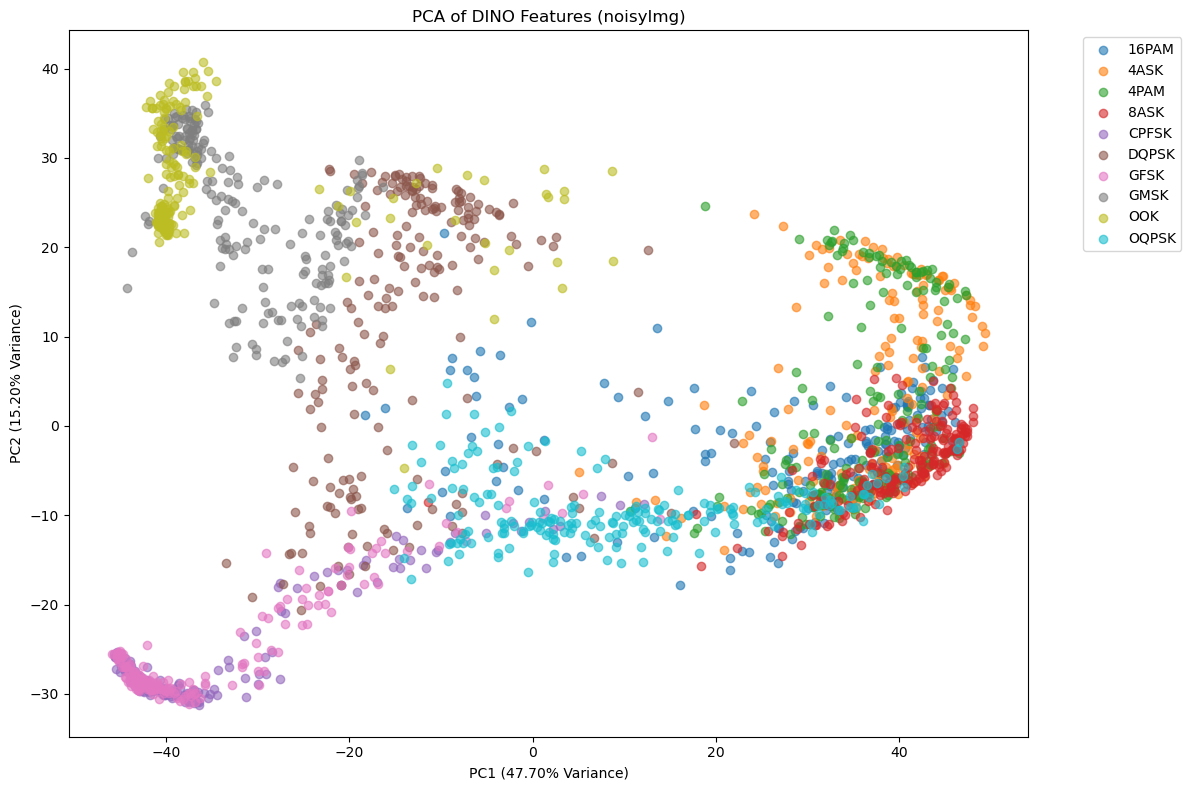

In [ ]:
# Save to JSON
save_results(all_results, OUTPUT_JSON)

In [ ]:
# (Optional) Visualise PCA of one feature type

Original Shape:    (2000, 10)
Discretized Shape: (2000, 10)

Sample 0 (Original): [ 32.57683362  -9.00705537 -14.40968801 -24.54482749  -1.89450703
  -3.87688594   6.71246381  -1.58820903  -3.75815241   0.46741915]
Sample 0 (Bins):     [8 3 3 2 4 4 8 4 5 4]


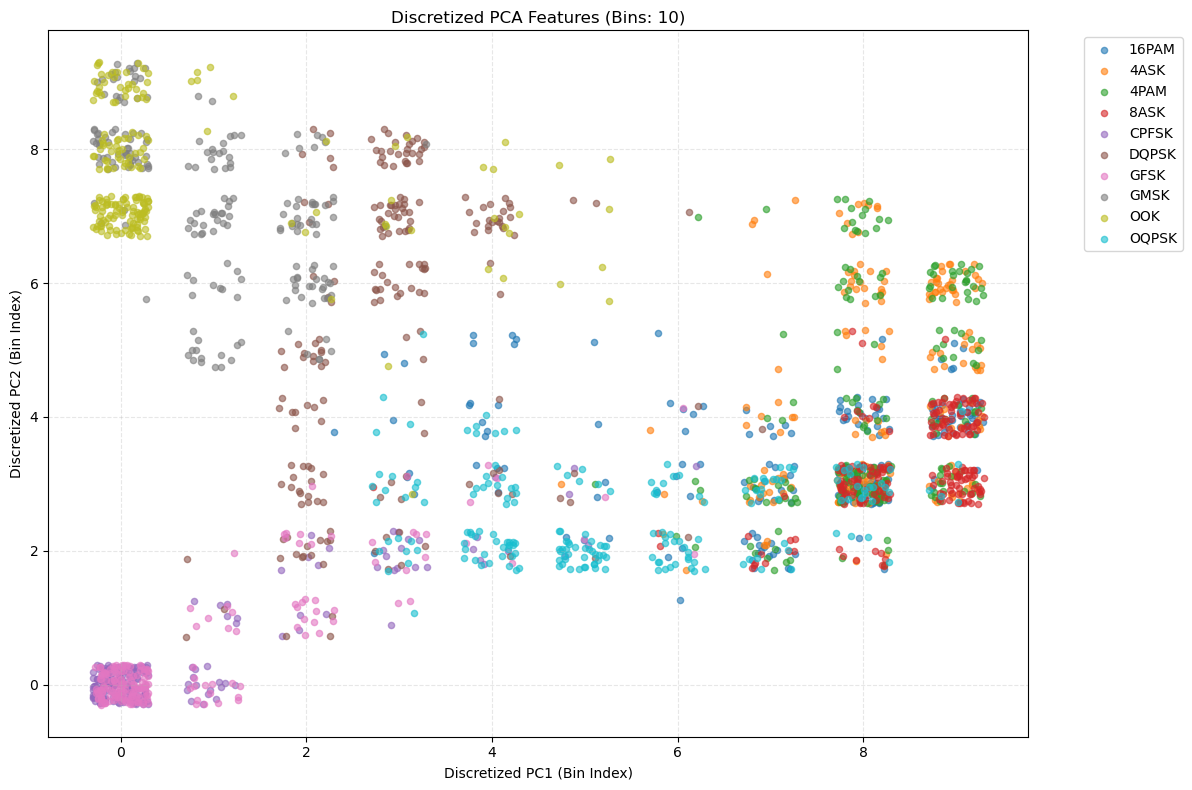

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from embedding_pipeline import extract_label

# Choose which feature_type to plot
feature_type = "noisyImg"

# Gather discretized vectors + labels from saved results
X_disc, labels = [], []
for fname, feat_dict in all_results.items():
    if feature_type in feat_dict:
        X_disc.append(feat_dict[feature_type])
        labels.append(extract_label(fname))

X_disc = np.array(X_disc)
labels = np.array(labels)

# Jittered scatter of the first two discretized PCA dimensions
plt.figure(figsize=(12, 8))
jitter = 0.3
X_jit = X_disc[:, :2] + np.random.uniform(-jitter, jitter, (len(X_disc), 2))
unique = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique)))

for i, lbl in enumerate(unique):
    mask = labels == lbl
    plt.scatter(X_jit[mask, 0], X_jit[mask, 1], label=lbl, alpha=0.6, color=colors[i], s=20)

plt.xlabel("Discretized PC1 (Bin Index)")
plt.ylabel("Discretized PC2 (Bin Index)")
plt.title(f"Discretized PCA Features – {feature_type} (bins={N_BINS})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Test .pkl files

In [14]:
import numpy as np
import pickle

# data_file_path = "../data/own/unlabeled_10k/test_centroid_noisySignal_5_5_emb10_data.pkl"
data_file_path = "/mnt/d/Rowan/discrete-llm-amc/data/own/unlabeled_10k/test_noisySignal_5_5_data.pkl"
with open(data_file_path, "rb") as f:
    data = pickle.load(f)   

data.keys()

dict_keys(['signal_paths', 'signals', 'stats', 'discret_stats', 'labels', 'snrs', 'prompts', 'discret_prompts', 'old_prompts', 'old_discret_prompts', 'feature_names', 'scaler', 'discretizers', 'num_samples', 'num_features', '#classes', '#snr', 'k-top'])

In [2]:
data['discret_stats']

[{'pc_0': np.int64(4),
  'pc_1': np.int64(1),
  'pc_2': np.int64(2),
  'pc_3': np.int64(1),
  'pc_4': np.int64(2),
  'pc_5': np.int64(2),
  'pc_6': np.int64(1),
  'pc_7': np.int64(4),
  'pc_8': np.int64(2),
  'pc_9': np.int64(3)},
 {'pc_0': np.int64(4),
  'pc_1': np.int64(1),
  'pc_2': np.int64(2),
  'pc_3': np.int64(1),
  'pc_4': np.int64(3),
  'pc_5': np.int64(3),
  'pc_6': np.int64(1),
  'pc_7': np.int64(3),
  'pc_8': np.int64(1),
  'pc_9': np.int64(3)},
 {'pc_0': np.int64(4),
  'pc_1': np.int64(1),
  'pc_2': np.int64(2),
  'pc_3': np.int64(1),
  'pc_4': np.int64(2),
  'pc_5': np.int64(2),
  'pc_6': np.int64(1),
  'pc_7': np.int64(4),
  'pc_8': np.int64(1),
  'pc_9': np.int64(3)},
 {'pc_0': np.int64(4),
  'pc_1': np.int64(1),
  'pc_2': np.int64(2),
  'pc_3': np.int64(1),
  'pc_4': np.int64(2),
  'pc_5': np.int64(2),
  'pc_6': np.int64(1),
  'pc_7': np.int64(4),
  'pc_8': np.int64(1),
  'pc_9': np.int64(3)},
 {'pc_0': np.int64(4),
  'pc_1': np.int64(1),
  'pc_2': np.int64(2),
  'pc_3

In [15]:
print(len(data['discret_prompts'][0]))

3807
